<a href="https://colab.research.google.com/github/Oscardobanks/machine_learning_practice/blob/main/Vectorised_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Google sheet.

google_sheet_id = '1ziWF38RKYvs4ysqwcuPRzC7N1WiX3hk7'

url = f'https://docs.google.com/uc?id={google_sheet_id}&export=download'

try:

    df = pd.read_csv(url)

    print("Google Sheet data loaded successfully:")

    display(df.head())

except Exception as e:

    print(f"Error loading Google Sheet: {e}")

Google Sheet data loaded successfully:


,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0


In [3]:
X1 = np.array(df['x1'])
X2 = np.array(df['x2'])
X3 = np.array(df['x3'])

X = np.column_stack((X1, X2, X3))

Y = np.array(df['label'])

display(X.shape, Y.shape)
X, Y

(200, 3)

(200,)

(array([[-3.32727288e-01, -6.96181041e-01, -2.86766581e-01],
        [-1.51022049e+00, -1.37586113e+00, -1.19725687e+00],
        [-1.25607624e+00, -1.22876370e+00, -1.78599642e+00],
        [-7.72276364e-01, -4.09598435e-01, -2.67973078e-01],
        [-1.34626309e+00,  1.12805059e-01,  6.12267555e-01],
        [ 2.15636892e-01,  2.98918001e-01,  1.03272447e+00],
        [ 6.70567936e-01,  1.92308238e-01,  1.64721375e+00],
        [-1.31646482e-01,  6.91599305e-01,  1.59772213e-02],
        [ 2.38841369e-01,  9.04251521e-01,  2.91584612e-01],
        [-6.28618178e-01, -3.27819886e-01, -3.79269256e-02],
        [ 1.20913644e+00,  7.92472643e-01, -4.47009021e-01],
        [ 9.40205968e-01,  1.49413905e+00,  3.53375636e-01],
        [-1.23353761e+00,  6.66406329e-03,  7.03680945e-01],
        [ 1.34774888e-01, -1.51270519e-01, -5.32092286e-01],
        [-3.77867697e-01,  5.61597099e-01,  1.07528066e-01],
        [ 7.44568943e-01,  2.67232902e-01,  9.54881922e-01],
        [-8.67011677e-01

In [42]:
# Initialize training parameters and hyperparameters
c, m1, m2, m3 = 0.2, 0.2, 0.2, 0.2
learning_rate = 0.1
epochs = 100_000
losses = []

In [43]:
z = m1 * X1 + m2 * X2 + m3 * X3 + c
z

array([-6.31349820e-02, -6.16667698e-01, -6.54167273e-01, -8.99695752e-02,
        7.57619042e-02,  5.09455872e-01,  7.02017984e-01,  3.15186009e-01,
        4.86935500e-01,  1.12700224e-03,  5.10920012e-01,  7.57544130e-01,
        9.53614806e-02,  9.02824165e-02,  2.58251494e-01,  5.93336753e-01,
        2.82035963e-02,  4.13362724e-01, -3.62482806e-01,  3.67583402e-01,
        4.54024085e-01,  8.41932779e-01,  2.33594892e-01,  5.49823073e-01,
        1.98994964e-01, -2.42756544e-01,  1.62683029e-01, -3.13966256e-03,
        6.40620337e-01,  2.89890177e-02,  1.38955699e-01,  3.72662142e-01,
        3.94426515e-02,  3.33344325e-01,  3.88432302e-01, -2.82608792e-02,
        5.48253144e-02,  2.23405198e-01,  3.01148620e-01,  8.22691281e-01,
       -2.13178474e-01,  9.56972157e-01,  7.35552388e-01,  4.80400139e-01,
        7.63421972e-01, -6.27916827e-01, -2.27741725e-01, -4.90368608e-01,
        5.07175664e-02,  9.06360398e-01,  6.07172093e-02,  7.07141908e-02,
       -8.08853115e-01, -

In [44]:
p = 1 / (1 + np.exp(-z))
p

array([0.4842215 , 0.35053971, 0.34205107, 0.47752277, 0.51893142,
       0.62467891, 0.66863503, 0.5781506 , 0.61938425, 0.50028175,
       0.62502212, 0.6808203 , 0.52382232, 0.52255529, 0.56420642,
       0.64413039, 0.50705043, 0.60189392, 0.41035868, 0.59087491,
       0.61159557, 0.69887213, 0.55813461, 0.63409454, 0.54958522,
       0.43960716, 0.5405813 , 0.49921509, 0.65489368, 0.50724675,
       0.53468314, 0.59210209, 0.50985938, 0.58257288, 0.59590525,
       0.49293525, 0.5137029 , 0.55562016, 0.57472328, 0.69480733,
       0.4469063 , 0.72251517, 0.67602252, 0.61784236, 0.68209622,
       0.34798304, 0.44330938, 0.37980674, 0.51267667, 0.71225481,
       0.51517464, 0.51767118, 0.30813494, 0.46431377, 0.39826706,
       0.49514558, 0.5825054 , 0.65466013, 0.51156304, 0.36176581,
       0.46645438, 0.48633148, 0.48581353, 0.73479105, 0.52343183,
       0.4998788 , 0.54425905, 0.47407614, 0.72056993, 0.48399306,
       0.47254353, 0.46392144, 0.64892981, 0.53343447, 0.46015

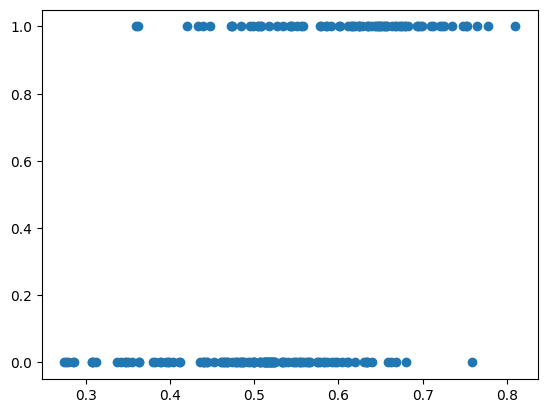

In [45]:
plt.scatter(p, Y)

In [46]:
def log_loss(y, p):
  # eps (epsilon) is a very low value used to avoid divide-by-zero or log of zero errors.
    eps = 1e-15
    # Clip probabilities to avoid log(0) and log(1) issues
    p_clipped = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p_clipped) + (1 - y) * np.log(1 - p_clipped))

In [49]:
# Vectorized Implementation of Logistic Regression
for epoch in range(epochs):
  # Calculate probability / prediction
  z = m1 * X1 + m2 * X2 + m3 * X3 + c
  p = 1 / (1 + np.exp(-z))
  loss = log_loss(Y, p)
  losses.append(loss)

  dm1 = -np.mean(X1 * (Y - p))
  dm2 = -np.mean(X2 * (Y - p))
  dm3 = -np.mean(X3 * (Y - p))
  dc = -np.mean(1 * (Y - p))

  m1 = m1 - learning_rate * dm1
  m2 = m2 - learning_rate * dm2
  m3 = m3 - learning_rate * dm3
  c = c - learning_rate * dc

# Print gradients.
print('loss:', loss, '\ndc:', dc, '\ndm1:', dm1, '\ndm2:', dm2, '\ndm3:', dm3)

loss: 0.02748166204845616 
dc: 6.563082689529875e-05 
dm1: -0.0005193049410478442 
dm2: 0.0003731815141752826 
dm3: -0.00025350879923566994


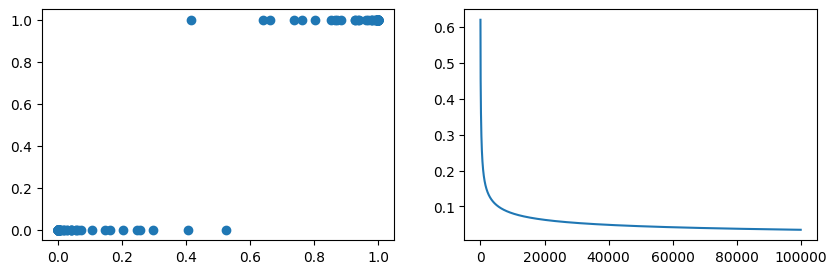

In [48]:
# Visualise the plot of Y against Y_hat (or P) to see how well the model performed
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.scatter(p, Y)

plt.subplot(1, 2, 2)
plt.plot(losses)